#Questão a ser respondida

##Quais ações tiveram mais volatilidade entre as altas e as baixas?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
from sklearn.model_selection import train_test_split

In [ ]:
dados = pd.read_csv('/content/all_stocks_5yr.csv')

# ANALISE EXPLORATÓRIA

In [ ]:
#Exibe as 10 primeira linhas
dados.head(10)

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
5,2013-02-15,13.93,14.61,13.93,14.50,15628000,AAL
6,2013-02-19,14.33,14.56,14.08,14.26,11354400,AAL
7,2013-02-20,14.17,14.26,13.15,13.33,14725200,AAL
8,2013-02-21,13.62,13.95,12.90,13.37,11922100,AAL
9,2013-02-22,13.57,13.60,13.21,13.57,6071400,AAL


In [ ]:
#Verificando o tipo dos dados
type(dados)

pandas.core.frame.DataFrame

In [ ]:
#Verificando quantidade de linhas e colunas
print(f'O dataset tem: {dados.shape[0]} linhas e {dados.shape[1]} colunas')

O dataset tem: 619040 linhas e 7 colunas


In [ ]:
#Vendo os nomes das colunas
print(f"As colunas são: {dados.columns}")

As colunas são: Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')


In [ ]:
#Vendo o tipo de dados de cada coluna
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


## Tratando dados faltantes

In [ ]:
dados.isnull().sum()

,0
date,0
open,11
high,8
low,8
close,0
volume,0
Name,0


Os dados faltantes são apenas das colunas 'open', 'high' e 'low'

A coluna 'open' representa o primeiro valor no qual a ação foi negociada no dia

A coluna 'high' representa o preço máximo da ação no dia

A coluna 'low' representa o menor preço registrado no dia

In [ ]:
#Como esses preços não tem uma variação grande de um dia para o outro, irei substituir esses dados faltantes pelo calculo da media do valor anterior com o valor sucessor
dados['open'] = dados['open'].interpolate(method='linear')
dados['low'] = dados['low'].interpolate(method='linear')
dados['high'] = dados['high'].interpolate(method='linear')

In [ ]:
dados.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
Name,0


In [ ]:
#Tratando o dado faltante da coluna nome
dados = dados.dropna(subset=['Name'])

In [ ]:
dados.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
Name,0


## Analise descritiva

In [ ]:
#Criando a coluna Year que irá representar o ano
#A ideia é separar as ações por ano e nome e pegar a media anual das altas e baixas
dados['date'] = pd.to_datetime(dados['date'])
dados['Year'] = dados['date'].dt.year
dados

,date,open,high,low,close,volume,Name,Year
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,2013
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL,2013
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL,2013
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL,2013
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL,2013
...,...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS,2018
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS,2018
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS,2018
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS,2018


In [ ]:
#Como o dataset é muito grande, dificulta muito a visualização dos dados
#Por isso, irei pegar os dados de apenas 3 ações para a conclusão do exercicio, o dataset pegou dados por 6 anos, cada ação tem dados de 6 anos
media_anual = dados.groupby(['Name', 'Year'])[['high', 'low']].mean().head(18)

In [ ]:
media_anual

high         low
Name Year                        
A    2013   47.520217   46.694402
     2014   54.578355   53.637273
     2015   39.941183   39.234304
     2016   43.731210   42.970086
     2017   59.731322   58.922418
     2018   72.121346   70.846538
AAL  2013   18.920291   18.308745
     2014   39.549713   38.229872
     2015   45.835482   44.447715
     2016   38.722188   37.607546
     2017   48.063533   46.932376
     2018   55.001877   53.568481
AAP  2013   87.282901   85.780794
     2014  132.192323  129.733411
     2015  165.379298  161.882606
     2016  157.084819  153.745721
     2017  124.129197  121.209156
     2018  116.209573  112.816923

In [ ]:
#Irei visualizar o desvio padrão desses dados
media_anual[:6].std() #AÇÃO A

,0
high,11.831106
low,11.648423


In [ ]:
media_anual[6:12].std() #AÇÃO AAL

,0
high,12.362296
low,12.092765


In [ ]:
media_anual[12:18].std()#AÇÃO AAP

,0
high,28.420472
low,27.826766


###VISUALIZAÇÃO GRAFICA

In [ ]:
#Aqui estou calculando o bins para usar no histograma
n_high = len(media_anual['high'])
bins_sturges_high = int(1 + np.log2(n_high))


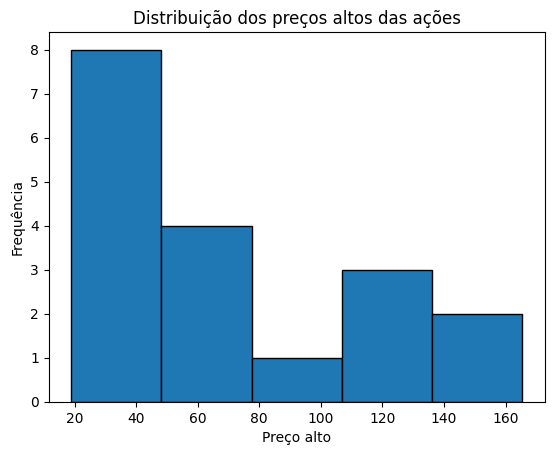

In [ ]:
plt.hist(media_anual['high'], bins=bins_sturges_high, edgecolor='black')
plt.title('Distribuição dos preços altos das ações')
plt.xlabel('Preço alto')
plt.ylabel('Frequência')
plt.show()

In [ ]:
n_low = len(media_anual['low'])
bins_sturges_low = int(1 + np.log2(n_low))

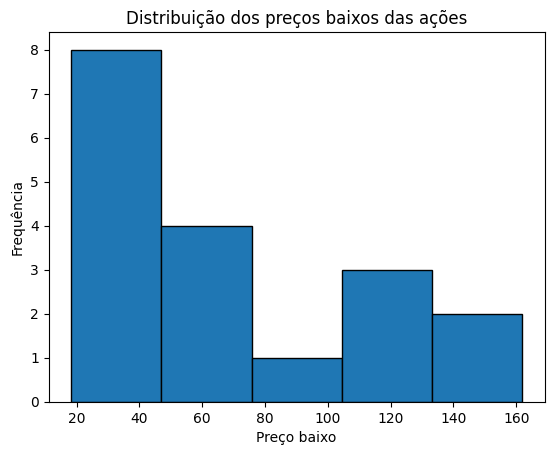

In [ ]:
plt.hist(media_anual['low'], bins=bins_sturges_low, edgecolor='black')
plt.title('Distribuição dos preços baixos das ações')
plt.xlabel('Preço baixo')
plt.ylabel('Frequência')
plt.show()

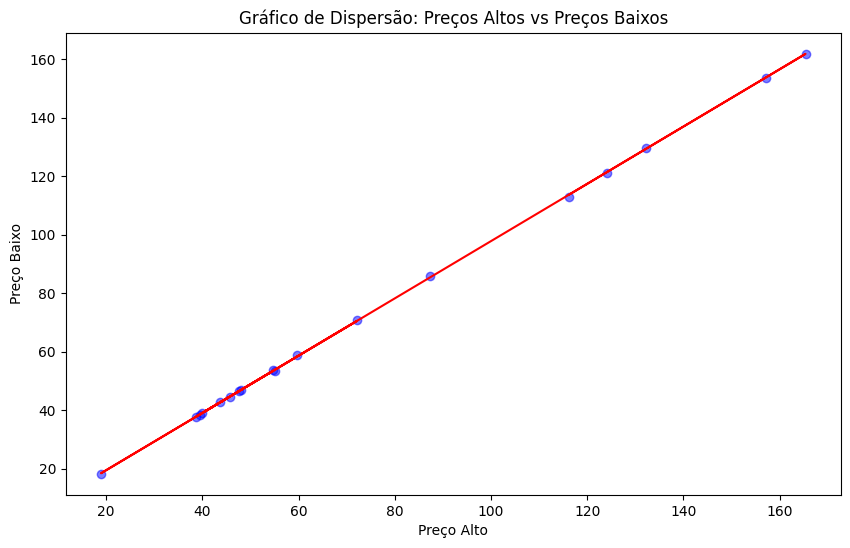

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(media_anual['high'], media_anual['low'], color='blue', alpha=0.5)
plt.title('Gráfico de Dispersão: Preços Altos vs Preços Baixos')
plt.xlabel('Preço Alto')
plt.ylabel('Preço Baixo')

m, b = np.polyfit(media_anual['high'], media_anual['low'], 1)  # 1 para uma linha reta
plt.plot(media_anual['high'], m * media_anual['high'] + b, color='red')  # Adicionando a linha de tendência

plt.show()

<Figure size 1500x800 with 0 Axes>

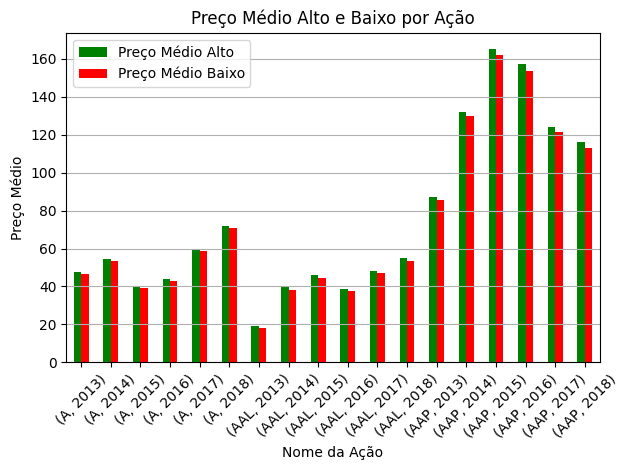

In [ ]:
plt.figure(figsize=(15, 8))  # Ajustar o tamanho do gráfico

# Plotar os dados
media_anual.plot(kind='bar', color=['green', 'red'])

# Adicionar título e rótulos
plt.title('Preço Médio Alto e Baixo por Ação')
plt.xlabel('Nome da Ação')
plt.ylabel('Preço Médio')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Adicionar legenda
plt.legend(['Preço Médio Alto', 'Preço Médio Baixo'])

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

Ao analisar o gráfico, observa-se que a ação da AAP apresentou a maior volatilidade em comparação com as demais. Essa conclusão indica que os preços da AAP exibiram oscilações significativas ao longo do período analisado, o que sugere um comportamento mais arriscado em relação aos investimentos nessa ação. A volatilidade elevada pode resultar de diversos fatores, como mudanças nas condições de mercado, variações na demanda e oferta, ou até mesmo eventos específicos que impactam a empresa. Essa informação é crucial para investidores que buscam compreender o perfil de risco associado à AAP em suas decisões de investimento.

##Criação do modelo supervisionado



In [ ]:
#Escolhi usar o modelo de classificação, a ideia é categorizar o risco de uma ação com base na volatilidade

#Separa os dados por ação e ano e calcula  desvio padrão
volatilidade = dados.groupby(['Name', 'Year'])[['high', 'low']].std().reset_index()

# Aqui estou categorizando o risco com base no desvio padrão
def categorizar_risco(row):
    if row['high'] < 2:
        return 'Baixo Risco'
    elif 2 <= row['high'] <= 5:
        return 'Risco Moderado'
    else:
        return 'Alto Risco'

volatilidade['Risco'] = volatilidade.apply(categorizar_risco, axis=1)


In [ ]:
volatilidade

,Name,Year,high,low,Risco
0,A,2013,4.588686,4.573514,Risco Moderado
1,A,2014,5.959446,5.911836,Alto Risco
2,A,2015,2.351678,2.427437,Risco Moderado
3,A,2016,3.550425,3.673470,Risco Moderado
4,A,2017,6.722210,6.654981,Alto Risco
...,...,...,...,...,...
2970,ZTS,2014,4.663882,4.495960,Risco Moderado
2971,ZTS,2015,2.226819,2.335277,Risco Moderado
2972,ZTS,2016,3.597875,3.752039,Risco Moderado
2973,ZTS,2017,6.023867,5.977551,Alto Risco


In [ ]:
X = volatilidade[['high', 'low']]
y = volatilidade['Risco']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


modelo_knn = KNeighborsClassifier(n_neighbors=5)

# Treinando do modelo
modelo_knn.fit(X_train, y_train)

# Previsão nos dados de teste
y_pred = modelo_knn.predict(X_test)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo KNN: {accuracy:.2f}')
print(classification_report(y_test, y_pred))

Acurácia do modelo KNN: 1.00
                precision    recall  f1-score   support

    Alto Risco       1.00      1.00      1.00       249
   Baixo Risco       1.00      1.00      1.00       108
Risco Moderado       1.00      1.00      1.00       238

      accuracy                           1.00       595
     macro avg       1.00      1.00      1.00       595
  weighted avg       1.00      1.00      1.00       595



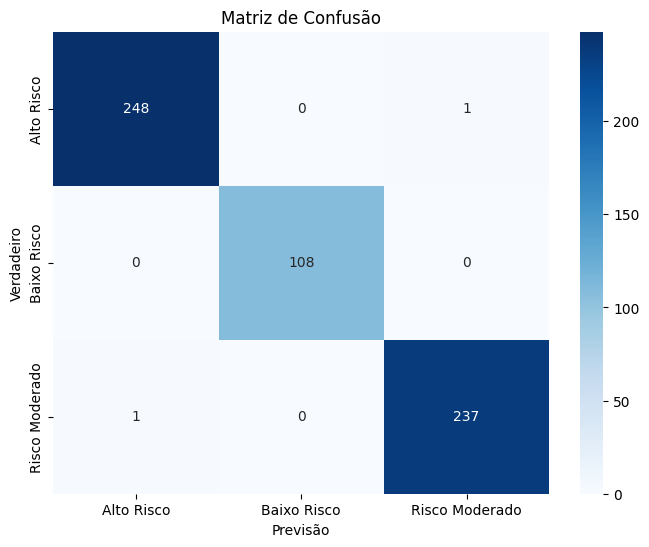

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Criar a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Visualizar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo_knn.classes_, yticklabels=modelo_knn.classes_)
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()
